# Лабораторна робота 2

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

## Алгоритм оптимізації роєм частинок
### $$ v_k = v_k + \alpha_1 (x_k^{best} - x_k) r_1 + \alpha_2 (x^* - x_k) r_2 $$
### $$α_1, α_2 ∈ (0; 4)$$

In [11]:
generations = 30

In [12]:
def pso(F, pop_size, x_min, x_max, v_min, v_max, alpha1, alpha2):

    X = np.random.uniform(x_min, x_max, (pop_size, 2))
    V = np.random.uniform(v_min, v_max, (pop_size, 2))

    X_best = X.copy()
    F_best = np.array([F(x) for x in X_best])

    k_best_value = np.argmin(F_best)
    x_best_value = X_best[k_best_value].copy()
    f_best_value = F_best[k_best_value]

    population_history = []
    best_history = []

    for _ in range(generations):

        population_history.append(X.copy())
        best_history.append(f_best_value)

        for k in range(pop_size):

            r1 = np.random.rand(2)
            r2 = np.random.rand(2)

            V[k] = (V[k] + alpha1 * r1 * (X_best[k] - X[k]) + alpha2 * r2 * (x_best_value - X[k]))

            V[k] = np.maximum(V[k], v_min)
            V[k] = np.minimum(V[k], v_max)

            X[k] = X[k] + V[k]

            for j in range(2):

                if X[k, j] < x_min[j]:
                    X[k, j] = x_min[j] + abs(X[k, j] - x_min[j])
                    V[k, j] = -V[k, j]

                if X[k, j] > x_max[j]:
                    X[k, j] = x_max[j] - abs(X[k, j] - x_max[j])
                    V[k, j] = -V[k, j]

            f_value = F(X[k])

            if f_value <= F_best[k]:
                X_best[k] = X[k].copy()
                F_best[k] = f_value

        k_best_value = np.argmin(F_best)

        if F_best[k_best_value] < f_best_value:
            x_best_value = X_best[k_best_value].copy()
            f_best_value = F_best[k_best_value]

    return x_best_value, f_best_value, population_history, best_history

### Function for visualizing the process of finding a global extremum.

In [13]:
def visualizing_the_process( pop_history, f, bounds_x, bounds_y, filename):

    x = np.linspace(bounds_x[0], bounds_x[1], 100)
    y = np.linspace(bounds_y[0], bounds_y[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = f((X, Y))

    fig = plt.figure(figsize=(15, 7))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2)

    def update(frame):

        ax1.clear()
        ax2.clear()

        pop = pop_history[frame]

        pop_x = np.array([p[0] for p in pop])
        pop_y = np.array([p[1] for p in pop])
        pop_z = f((pop_x, pop_y))

        ax1.plot_surface(X, Y, Z, cmap='plasma', alpha=0.7)
        ax1.scatter(pop_x, pop_y, pop_z, color='red', s=20)
        ax1.set_title(f"3D Графік")

        ax2.contourf(X, Y, Z, levels = 50, cmap='plasma')
        ax2.scatter(pop_x, pop_y, color = 'red', s = 20)
        ax2.set_title(f"Контурний графік ")
        ax2.set_xlim(bounds_x)
        ax2.set_ylim(bounds_y)
        
        fig.suptitle(f"Generation {frame}", fontsize=16)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames = len(pop_history),
        interval = 600,
        repeat = False
    )

    ani.save(filename, writer="pillow")
    plt.close(fig)

### Function to plot the objective function and the relationship between iteration number and best value

In [14]:
def plot_and_experiments(func, hyperparams, bounds_x, bounds_y, title, point, best_value):

    results = []

    x_min = np.array([bounds_x[0], bounds_x[0]])
    x_max = np.array([bounds_x[1], bounds_x[1]])
    v_min = np.array([-1, -1])
    v_max = np.array([1, 1])

    for pop_size, alpha1, alpha2 in hyperparams:

        best_x, best_f, population_history, best_history = pso(
            func, pop_size,  x_min, x_max, v_min, v_max,
            alpha1, alpha2
        )

        results.append({
            "pop_size": pop_size,
            "alpha1": alpha1,
            "alpha2": alpha2,
            "best_history": best_history,
            "best_solution": best_x,
            "best_f": best_f
        })

    fig = plt.figure(figsize=(12,5))
    fig.suptitle(f"Найкраще рішення: (x, y) = {point}, \nf(x) = {best_value:.4f}", fontsize=14)

    ax1 = fig.add_subplot(1,2,1, projection='3d')

    x = np.linspace(bounds_x[0], bounds_x[1], 100)
    y = np.linspace(bounds_y[0], bounds_y[1], 100)

    X, Y = np.meshgrid(x, y)
    Z = func((X, Y))

    ax1.plot_surface(X, Y, Z, cmap='plasma', alpha=0.9)

    x_p, y_p = point
    z_p = func(point)
    ax1.scatter(x_p, y_p, z_p, color='red', s=50)

    ax1.set_title(title)
    ax2 = fig.add_subplot(1,2,2)

    for result in results:
        ax2.plot(
            result["best_history"],
            linewidth=2,
            label=f"pop_size = {result['pop_size']}, alpha1 = {result['alpha1']}, alpha1 = {result['alpha2']}"
        )

    ax2.set_xlabel("Номер ітерації")
    ax2.set_ylabel("Найкраще значення функції")
    ax2.set_title("Графік збіжністі")
    ax2.grid()
    ax2.legend()

    plt.tight_layout()
    plt.show()

### Функцій пристосованості:

In [15]:
def f_ackley(v):
    x, y = v
    return (-20*np.exp(-0.2*np.sqrt(0.5*(x**2 + y**2)))
            - np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
            + np.e + 20)
    
def f_rosenbrock(v):
    n = len(v)
    s = 0
    for i in range(n - 1):
        s += 100*(v[i+1] - v[i]**2)**2 + (v[i] - 1)**2
    return s

def f_cross_in_tray(v):
    x, y = v
    term = np.abs(np.sin(x) * np.sin(y) *
                  np.exp(np.abs(100 - np.sqrt(x**2 + y**2)/np.pi)))
    return -0.0001 * (term + 1)**0.1

def f_holder_table(v):
    x, y = v
    return -np.abs(np.sin(x) * np.cos(y) *
                   np.exp(np.abs(1 - np.sqrt(x**2 + y**2)/np.pi)))
    
def f_cormick(v):
    x, y = v
    return np.sin(x + y) + (x - y)**2 - 1.5*x + 2.5*y + 1

def f_styblinski_tang(v):
    s = 0
    for x in v:
        s += x**4 - 16*x**2 + 5*x
    return s / 2

In [16]:
FUNCTIONS = {

    "ackley": {
        "func": f_ackley,
        "bounds": [(-5, 5), (-5, 5)],
        "name": "Ackley function",
        "hyperparams" :  [ (50, 2.0, 2.0),
                          (80, 1.3, 2.5),
                          (30, 2.3, 1.6)]
    },
    
    "rosenbrock": {
        "func": f_rosenbrock,
        "bounds": [(-2, 2), (-1, 3)],
        "name": "Rosenbrock function",
        "hyperparams" :  [(50, 2.0, 2.0),
                          (70, 1.1, 2.7),
                          (35, 2.4, 1.5)]
    },

    "cross_in_tray": {
        "func": f_cross_in_tray,
        "bounds": [(-10, 10), (-10, 10)],
        "name": "Cross-in-Tray function",
        "hyperparams" :  [(50, 2.0, 2.0),
                          (75, 1.2, 2.7),
                          (30, 2.3, 1.8)]
    },
    
    "holder_table": {
        "func": f_holder_table,
        "bounds": [(-10, 10), (-10, 10)],
        "name": "Holder table function",
        "hyperparams" :  [ (50, 2.0, 2.0),
                          (85, 1.4, 2.6),
                          (20, 2.5, 1.3)]
    },

    "cormick": {
        "func": f_cormick,
        "bounds": [(-1.5, 4), (-3, 4)],
        "name": "McCormick function",
        "hyperparams" :  [(50, 2.0, 2.0),
                          (30, 1.5, 2.4),
                          (80, 2.2, 1.8)]
    },

    "styblinski_tang": {
        "func": f_styblinski_tang,
        "bounds": [(-5, 5), (-5, 5)],
        "name": "Styblinski_tang function",
        "hyperparams" :  [ (50, 2.0, 2.0),
                          (35, 1.7, 2.2),
                          (75, 2.1, 1.8)]
    }
}

def get_function(key):

    key = key.lower()

    func_data = FUNCTIONS[key]
    f = func_data["func"]
    bounds = func_data["bounds"]
    a = (bounds[0][0], bounds[0][1])
    b = (bounds[1][0], bounds[1][1])
    name = func_data["name"]
    hyperparams = func_data["hyperparams"]
    
    return f, a, b, name, hyperparams

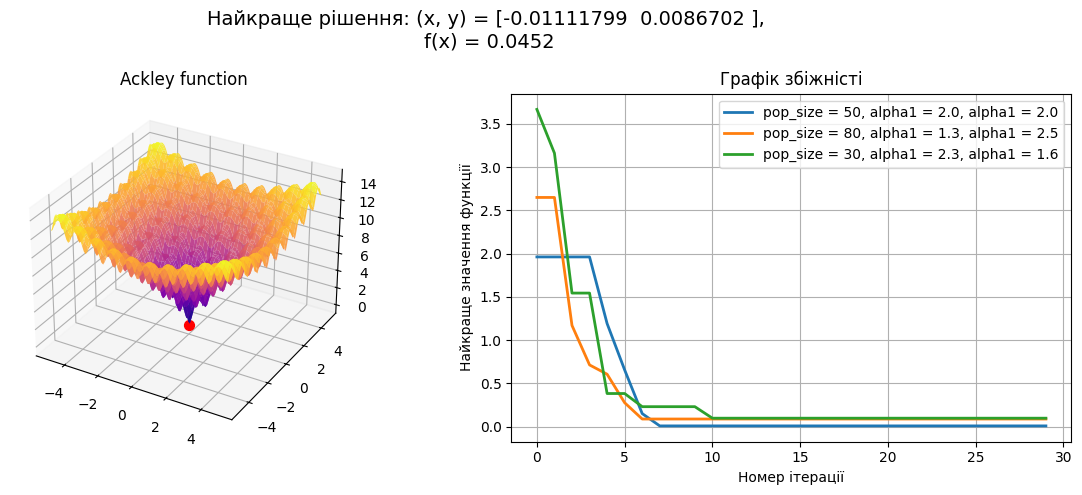

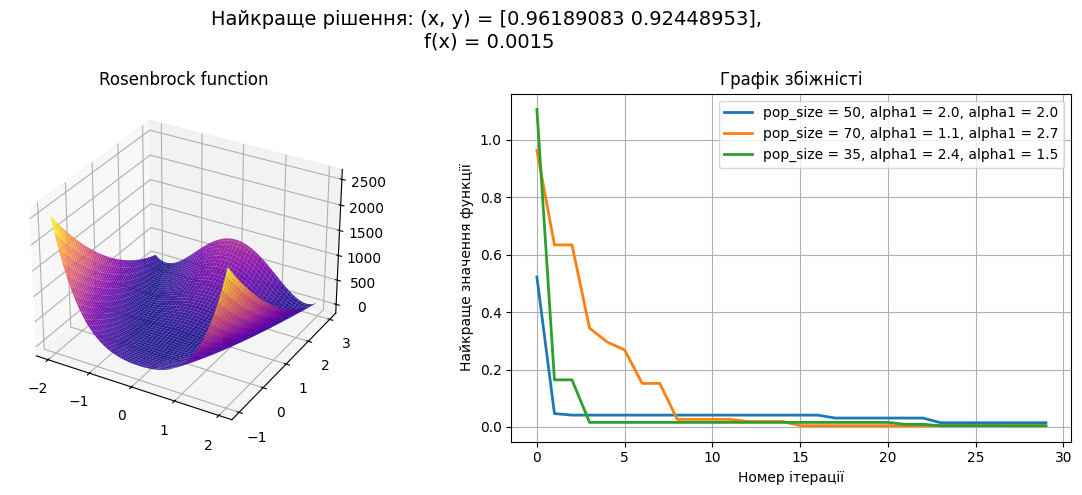

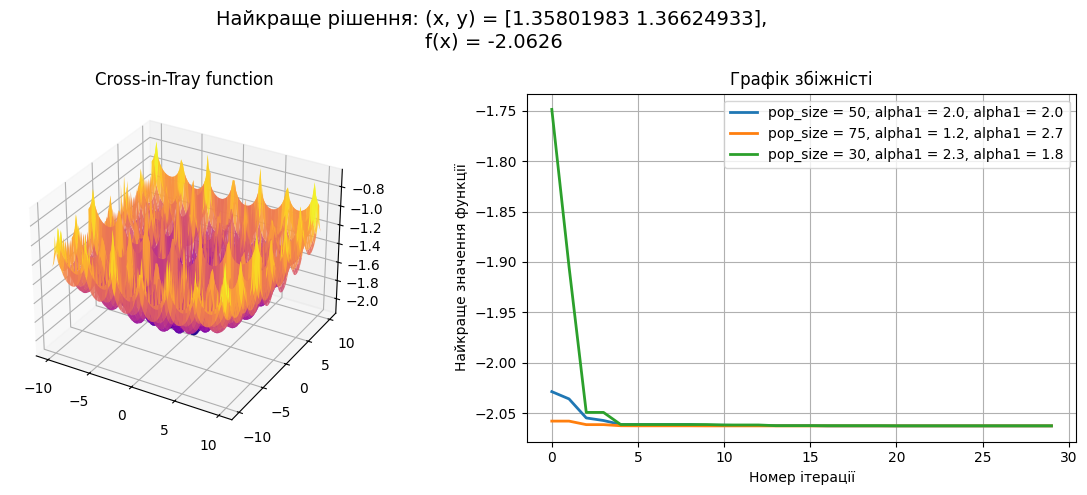

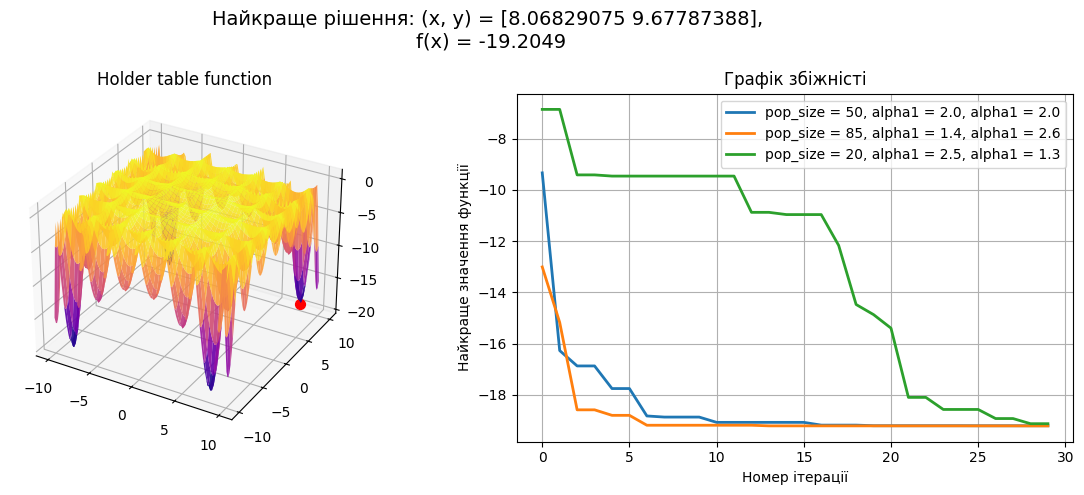

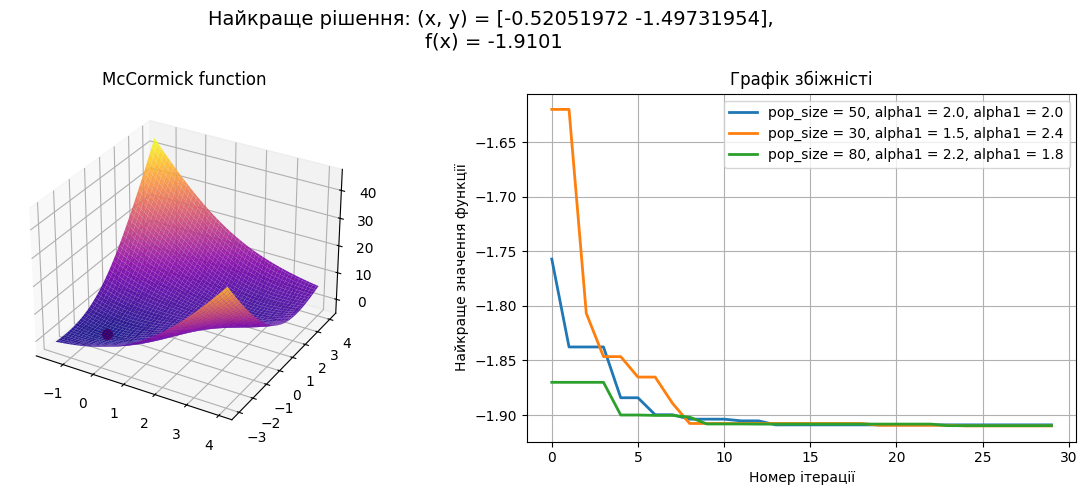

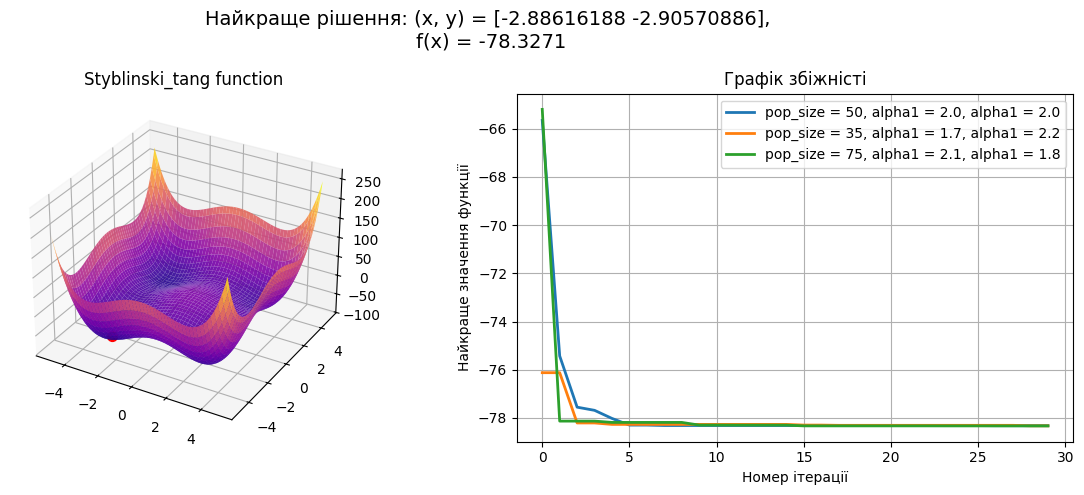

In [17]:
for key in FUNCTIONS.keys():

    f, a, b, name, hyperparams = get_function(key) 
    
    x_min = np.array([a[0], a[0]])
    x_max = np.array([a[1], a[1]])
    v_min = np.array([-1, -1])
    v_max = np.array([1, 1])
    
    best_x, best_f, population_history, best_history = pso( f, 50, x_min, x_max, v_min, v_max, alpha1 =2.0, alpha2 =2.0)
    
    plot_and_experiments(f, hyperparams, a, b, title = name , point = best_x, best_value = best_f )
    visualizing_the_process( population_history, f, a, b, f"{key}.gif")